In [2]:
# Copyright (C) 2024 Richard Stiskalek
# This program is free software; you can redistribute it and/or modify it
# under the terms of the GNU General Public License as published by the
# Free Software Foundation; either version 3 of the License, or (at your
# option) any later version.
#
# This program is distributed in the hope that it will be useful, but
# WITHOUT ANY WARRANTY; without even the implied warranty of
# MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the GNU General
# Public License for more details.
#
# You should have received a copy of the GNU General Public License along
# with this program; if not, write to the Free Software Foundation, Inc.,
# 51 Franklin Street, Fifth Floor, Boston, MA  02110-1301, USA.
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
import seaborn as sns

from reconstruction_comparison import *
import csiborgtools

%load_ext autoreload
%autoreload 2
%matplotlib inline

paths = csiborgtools.read.Paths(**csiborgtools.paths_glamdring)
fdir = "/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity"

In [3]:
h = 0.6766
cosmo = {"h": h, "Om": 0.3111, "Ob": 0.02242 / h**2, "ns": 0.9665,
         "tau": 0.0561, "mnu": 0, "w0": -1, "wa": 0, "As": 2.105}


In [4]:
f_nonlinear_to_linear_sigma8 = csiborgtools.flow.make_nonlinear_to_linear_sigma8(0.5, 1.2, 1000, **cosmo)

Computing linear sigma8:   0%|          | 0/1000 [00:00<?, ?it/s]

Computing linear sigma8: 100%|██████████| 1000/1000 [00:18<00:00, 54.97it/s]


### Compare Deaglan's result to Juszkiewicz

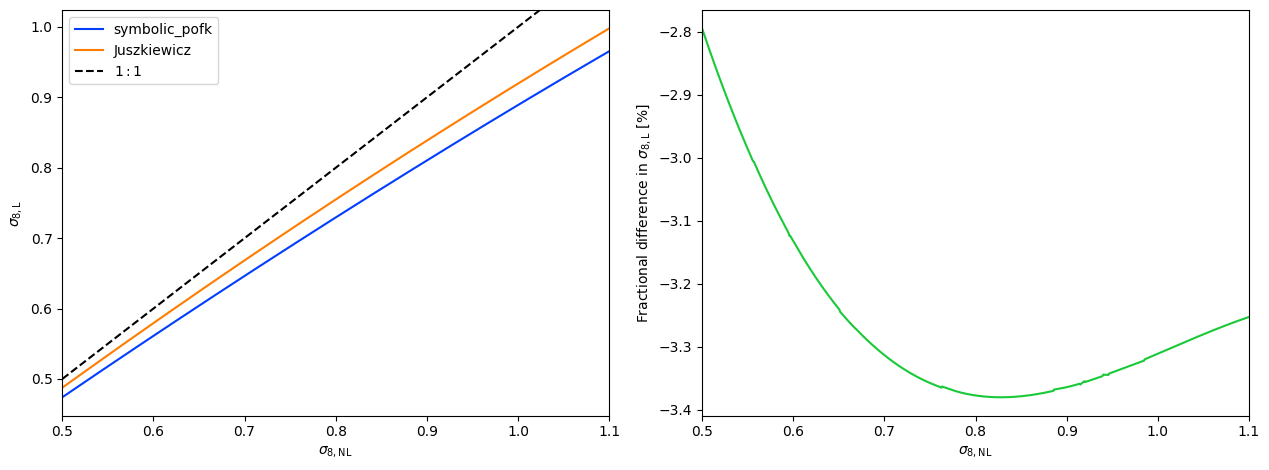

In [29]:
fig, axs = plt.subplots(1, 2, figsize=(2 * 6.4, 4.8), sharex=True)
cols = sns.color_palette("bright")

x = np.linspace(0.5, 1.1, 1000)
y1 = f_nonlinear_to_linear_sigma8(x)
y2 = csiborgtools.flow.sigma8_nonlinear_to_linear_juszkiewicz(x)


axs[0].plot(x, y1, label=r"symbolic_pofk", c=cols[0])
axs[0].plot(x, y2, label="Juszkiewicz", c=cols[1])
axs[0].axline((0.5, 0.5), slope=1, color='k', linestyle='--', c="black", label=r"$1:1$")
axs[1].plot(x, (y1 - y2) / y2 * 100, c=cols[2])

axs[0].set_xlim(x.min(), x.max())

for i in range(2):
    axs[i].set_xlabel(r"$\sigma_{8, \mathrm{NL}}$")
axs[0].set_ylabel(r"$\sigma_{8, \mathrm{L}}$")
axs[1].set_ylabel(r"Fractional difference in $\sigma_{8, \mathrm{L}}$ [%]")

axs[0].legend()
fig.tight_layout()
plt.savefig("../../plots/sigma8_mapping_comparison.png", dpi=450)

fig.show()

In [64]:
simname = "Carrick2015"

fname = paths.flow_validation(
    fdir, simname, catalogue="CF4_TFR_i", inference_method="bayes",
    sample_alpha=True, sample_beta=None,
    zcmb_max=0.05)
beta_CF4_TFR_i = get_some_samples(fname, ["beta"])["beta"]

fname = paths.flow_validation(
    fdir, simname, catalogue="CF4_TFR_w1", inference_method="bayes",
    sample_alpha=True, sample_beta=None,
    zcmb_max=0.05)
beta_CF4_TFR_w1 = get_some_samples(fname, ["beta"])["beta"]


fname = paths.flow_validation(
    fdir, simname, catalogue=["LOSS", "Foundation", "CF4_TFR_i", "CF4_TFR_notSDSS_w1"], inference_method="bayes",
    sample_alpha=True, sample_beta=None,
    zcmb_max=0.05)
beta_joint = get_some_samples(fname, ["beta"])["beta"]

fname = paths.flow_validation(
    fdir, simname, catalogue="2MTF", inference_method="bayes",
    sample_alpha=True, sample_beta=None,
    zcmb_max=0.05)
beta_2MTF = get_some_samples(fname, ["beta"])["beta"]


def compute_fsigma8_nonlinear(beta, which_sigma8g):
    if which_sigma8g == "westover":
        sigma8g_mean = 0.98
        sigma8g_std = 0.07
    elif which_sigma8g == "carrick":
        sigma8g_mean = 0.99
        sigma8g_std = 0.04
    else:
        raise ValueError(f"`which_sigma8g` {which_sigma8g} not recognized")
    
    sigma8g = np.random.normal(sigma8g_mean, sigma8g_std, size=len(beta))
    return beta * sigma8g

def compute_sigma8_nonlinear(fsig8_nonlinear, Om0, gamma=6/11):
    return fsig8_nonlinear / (Om0**gamma)


# sig8_linear_planck = np.random.normal(0.8159, 0.0086, size=len(beta))

File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_Carrick2015_CF4_TFR_i_bayes_zcmb_max_0.05_sample_alpha.hdf5
Last modified: 12/09/2024 12:20:11
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_Carrick2015_CF4_TFR_w1_bayes_zcmb_max_0.05_sample_alpha.hdf5
Last modified: 11/10/2024 16:15:57
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_Carrick2015_LOSS_Foundation_CF4_TFR_i_CF4_TFR_notSDSS_w1_bayes_zcmb_max_0.05_sample_alpha.hdf5
Last modified: 19/11/2024 14:38:27
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_Carrick2015_2MTF_bayes_zcmb_max_0.05_sample_alpha.hdf5
Last modified: 21/10/2024 11:10:15


### Plot of $\beta$

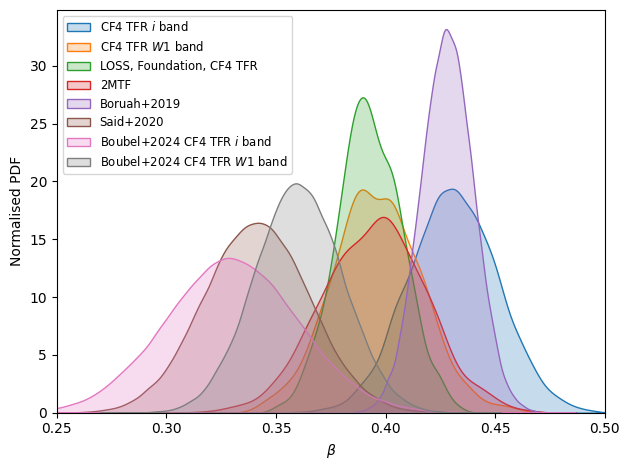

In [86]:
from scipy.stats import norm


catalogues = ["LOSS", "Foundation", "2MTF", "SFI_gals", "CF4_TFR_i", "CF4_TFR_w1", ]


plt.figure()
cols = sns.color_palette()

sns.kdeplot(beta_CF4_TFR_i, label=r"CF4 TFR $i$ band", fill=True, color=cols[0])
sns.kdeplot(beta_CF4_TFR_w1, label=r"CF4 TFR $W1$ band", fill=True, color=cols[1])
sns.kdeplot(beta_joint, label="LOSS, Foundation, CF4 TFR", fill=True, color=cols[2])
sns.kdeplot(beta_2MTF, label="2MTF", fill=True, color=cols[3])

d = norm(0.428, 0.012)
xs = d.rvs(100_000)
sns.kdeplot(xs, label="Boruah+2019", fill=True, color=cols[4])


d = norm(0.341, 0.024)
xs = d.rvs(100_000)
sns.kdeplot(xs, label="Said+2020", fill=True, color=cols[5])



d = norm(0.33, 0.03)
xs = d.rvs(100_000)
sns.kdeplot(xs, label="Boubel+2024 CF4 TFR $i$ band", fill=True, color=cols[6])

d = norm(0.36, 0.02)
xs = d.rvs(100_000)
sns.kdeplot(xs, label="Boubel+2024 CF4 TFR $W1$ band", fill=True, color=cols[7])


plt.xlim(0.25, 0.5)

plt.xlabel(r"$\beta$")
plt.ylabel("Normalised PDF")
plt.legend(loc="upper left", fontsize="small")

plt.tight_layout()
plt.savefig("../../plots/C15_beta.png", dpi=450)

plt.show()

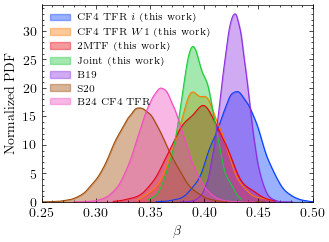

In [149]:
from scipy.stats import gaussian_kde, norm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Helper function to normalize KDE plots
def plot_normalized_kde(data, label, color, norm_factor=None):
    # Compute the KDE explicitly
    kde = gaussian_kde(data)
    x_vals = np.linspace(data.min(), data.max(), 500)
    y_vals = kde(x_vals)

    # Normalize y-values
    if norm_factor is not None:
        y_vals_normalized = y_vals / norm_factor
    else:
        y_vals_normalized = y_vals
    # Plot the normalized KDE
    plt.plot(x_vals, y_vals_normalized, color=color, label=None, lw=plt.rcParams["lines.linewidth"] * 0.75)
    plt.fill_between(x_vals, y_vals_normalized, color=color, alpha=0.4, label=label)

# Data and plotting
with plt.style.context("science"):
    plt.figure()
    cols = sns.color_palette("bright")

    # Replace with your actual data arrays
    plot_normalized_kde(beta_CF4_TFR_i, r"CF4 TFR $i$ (this work)", cols[0])
    plot_normalized_kde(beta_CF4_TFR_w1, r"CF4 TFR $W1$ (this work)", cols[1])
    plot_normalized_kde(beta_2MTF, "2MTF (this work)", cols[3])
    plot_normalized_kde(beta_joint, "Joint (this work)", cols[2])

    # Norm-distributed data
    d = norm(0.428, 0.012)
    xs = d.rvs(100_000)
    plot_normalized_kde(xs, "B19", cols[4])

    d = norm(0.341, 0.024)
    xs = d.rvs(100_000)
    plot_normalized_kde(xs, "S20", cols[5])

    # d = norm(0.33, 0.03)
    # xs = d.rvs(100_000)
    # plot_normalized_kde(xs, r"B24 CF4 TFR $i$ band", cols[6])

    d = norm(0.36, 0.02)
    xs = d.rvs(100_000)
    plot_normalized_kde(xs, r"B24 CF4 TFR", cols[6])

    # Adjust plot limits and labels
    plt.xlim(0.25, 0.5)
    plt.ylim(0)
    plt.xlabel(r"$\beta$")
    plt.ylabel("Normalized PDF")
    plt.legend(loc="upper left", fontsize="x-small")

    # Save and show plot
    plt.tight_layout()
    plt.savefig("../../plots/C15_beta.pdf", dpi=450)
    plt.show()


### Plot of $f \sigma_{8, \mathrm{NL}}$

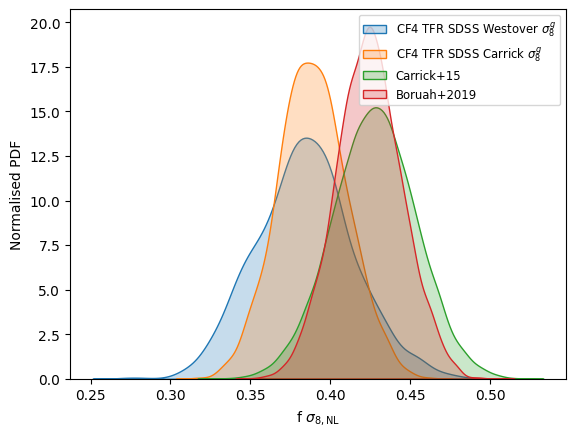

In [56]:
from scipy.stats import norm

plt.figure()
sns.kdeplot(compute_fsigma8_nonlinear(beta_joint, "westover"),
            label=r"CF4 TFR SDSS Westover $\sigma_8^g$", fill=True)
sns.kdeplot(compute_fsigma8_nonlinear(beta_joint, "carrick"),
            label=r"CF4 TFR SDSS Carrick $\sigma_8^g$", fill=True)


xs = norm(0.427, 0.026).rvs(size=10_000)
sns.kdeplot(xs, label=simname_to_pretty("Carrick2015"), fill=True)


betas_boruah = norm(0.428, 0.012).rvs(size=10_000)
sns.kdeplot(compute_fsigma8_nonlinear(betas_boruah, "carrick"), label="Boruah+2019", fill=True)

plt.xlabel(r"f $\sigma_{8, \mathrm{NL}}$")
plt.ylabel(r"Normalised PDF")
plt.legend(fontsize="small")
plt.savefig("../../plots/fsigma8_nl_comparison.png", dpi=450)
plt.show()


### Plot of $f \sigma_{8, \mathrm{L}}$

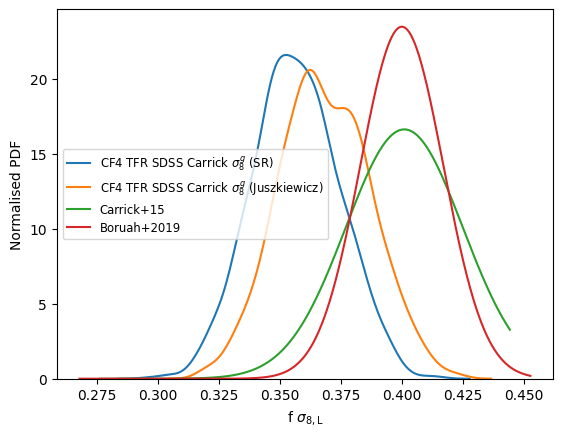

In [57]:
def fsigma8_nonlinear_to_linear(fsigma8_nonlinear, Om0, gamma=6/11, which="sr"):
    sigma8_nonlinear = fsigma8_nonlinear / Om0**gamma

    if which == "sr":
        return f_nonlinear_to_linear_sigma8(sigma8_nonlinear) * Om0**gamma
    elif which == "juszkiewicz":
        return csiborgtools.flow.sigma8_nonlinear_to_linear_juszkiewicz(sigma8_nonlinear) * Om0**gamma
    else:
        raise ValueError(f"`which` {which} not recognized")


fill = False

plt.figure()
sns.kdeplot(fsigma8_nonlinear_to_linear(compute_fsigma8_nonlinear(beta_joint, "carrick"), 0.3, which="sr"),
            fill=fill, label=r"CF4 TFR SDSS Carrick $\sigma_8^g$ (SR)",)
sns.kdeplot(fsigma8_nonlinear_to_linear(compute_fsigma8_nonlinear(beta_joint, "carrick"), 0.3, which="juszkiewicz"),
            fill=fill, label=r"CF4 TFR SDSS Carrick $\sigma_8^g$ (Juszkiewicz)",)

d = norm(0.401, 0.024)
xs = np.linspace(*plt.xlim(), 1000)
plt.plot(xs, d.pdf(xs), label=simname_to_pretty("Carrick2015"))

d = norm(0.400, 0.017)
xs = np.linspace(*plt.xlim(), 1000)
plt.plot(xs, d.pdf(xs), label="Boruah+2019")


plt.xlabel(r"f $\sigma_{8, \mathrm{L}}$")
plt.ylabel(r"Normalised PDF")
plt.legend(fontsize="small")
plt.savefig("../../plots/fsigma8_linear_comparison.png", dpi=450)

plt.show()


### Plot of $S_8$

In [87]:
def fsigma8_nonlinear_to_S8(fsigma8_nonlinear, Om0, gamma=0.55, which="sr"):
    sigma8_nonlinear = fsigma8_nonlinear / Om0**gamma

    if which == "sr":
        sigma8_linear = f_nonlinear_to_linear_sigma8(sigma8_nonlinear)
    elif which == "juszkiewicz":
        sigma8_linear = csiborgtools.flow.sigma8_nonlinear_to_linear_juszkiewicz(sigma8_nonlinear)
    else:
        raise ValueError(f"`which` {which} not recognized")

    return sigma8_linear * (Om0 / 0.3)**gamma
    

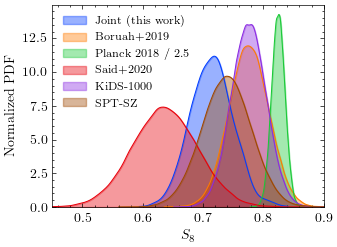

In [150]:
from scipy.stats import gaussian_kde

# Helper function to normalize KDE plots
def plot_normalized_kde(data, label, color, norm_factor=None):
    # Compute the KDE explicitly
    kde = gaussian_kde(data)
    x_vals = np.linspace(data.min(), data.max(), 500)
    y_vals = kde(x_vals)

    # Normalize y-values
    if norm_factor is not None:
        y_vals_normalized = y_vals / norm_factor
    else:
        y_vals_normalized = y_vals
    # Plot the normalized KDE
    plt.plot(x_vals, y_vals_normalized, color=color, label=None, lw=plt.rcParams["lines.linewidth"] * 0.75)
    plt.fill_between(x_vals, y_vals_normalized, color=color, alpha=0.4, label=label)


with plt.style.context("science"):
    plt.figure()
    cols = sns.color_palette("bright")

    # # Custom inputs and plotting
    # plot_normalized_kde(
    #     fsigma8_nonlinear_to_S8(compute_fsigma8_nonlinear(beta_joint, "carrick"), 0.3, which="sr"),
    #     r"LOSS, Foundation, CF4 TFR (symbolic_pofk)", cols[0]
    # )

    plot_normalized_kde(
        fsigma8_nonlinear_to_S8(compute_fsigma8_nonlinear(beta_joint, "carrick"), 0.3, which="juszkiewicz"),
        r"Joint (this work)", cols[0]
    )

    d = norm(0.776, 0.033)
    xs = d.rvs(100_000)
    plot_normalized_kde(xs, "Boruah+2019", cols[1])

    d = norm(0.825, 0.011)
    xs = d.rvs(100_000)
    plot_normalized_kde(xs, "Planck 2018 / 2.5", cols[2], norm_factor=2.5)

    d = norm(0.637, 0.054)
    xs = d.rvs(100_000)
    plot_normalized_kde(xs, "Said+2020", cols[3])

    d = norm(0.776, 0.029)
    xs = d.rvs(100_000)
    plot_normalized_kde(xs, "KiDS-1000", cols[4])

    d = norm(0.739, 0.041)
    xs = d.rvs(100_000)
    plot_normalized_kde(xs, "SPT-SZ", cols[5])

    plt.xlabel(r"$S_8$")
    plt.ylabel(r"Normalized PDF")
    plt.ylim(0)
    plt.xlim(0.45, 0.90)
    plt.legend(fontsize="small", loc="upper left")
    plt.savefig("../../plots/S8_comparison.pdf", dpi=450)
    plt.show()
